## Exercise 1: Metropolis sampling and the Ising model

**1.1. Sampling a weighted die:** consider a discrete variable $x \in \{1,2,3,4,5,6\}$, with probability
$$
\pi (x) = \frac{w(x)}{Z}, \qquad w(x)=x, \qquad Z = \sum_{x=1}^{6}w(x).
$$

Starting from a state $x$, propose a new state $y$ uniformly from all six possibilities, including the current state. Accept the proposal with probability
$$
a(x,y) = \min\left(1,\frac{w(y)}{w(x)} \right) = \min\left( 1, \frac{y}{x} \right)
$$
If the proposal is rejected, retain $x$.

**(a)** Implement this Markov chain. Compare the empirical frequencies and sample mean with their exact values as the number of samples increases.

- Fix x, look at $a(y) = \min(1, \frac{y}{x})$. $a(y)$ is 1 if $y\geq x$. Otherwise $x>y$, and $a(y) = \frac{y}{x}$.

- Suppose we propose y from the discrete sample space. If $y\geq x$, then accept. 

- If $x>y$, we want to accept with probability $\frac{y}{x}$. Draw $u$ from $U$ on $[0,1)$. If $u < y/x$, then accept. Otherwise, reject and retain $x$.

In [56]:
from numpy.random import rand, choice
import numpy as np
import matplotlib.pyplot as plt

space = [1,2,3,4,5,6]

x_init = choice(space)

def sample_from_a(x,y): # returns bool
    if y >= x:
        return False

    u = rand()
    if u < y/x:
        return False
    
    return True

def step(x): # return next element in chain
    y = choice(space)

    # we want reject to be a random bool distributed according to 1 - a(x,y).
    reject = sample_from_a(x,y)

    if reject:
        return x
    
    return y

def generate_chain(N):
    X = np.zeros(N)
    X[0] = x_init

    for i in range(N-1):
        X[i+1] = step(X[i])
    return X


Instead of plotting a load of histograms, a plot of some error norm (here, RMSE) against $N$ is better.

$ \text{RMSE}(N) = \sqrt{\frac{1}{6}\sum_{k=1}^6 \left(\hat{p}_N(k) - \pi(k) \right)^2}$,

where $\hat{p}_N(k)$ is the fraction of the N samples equal to $k\in\{1,2,3,4,5,6\}$, and $\pi(k) = \frac{w(k)}{Z}$ is the distribution, as defined already.

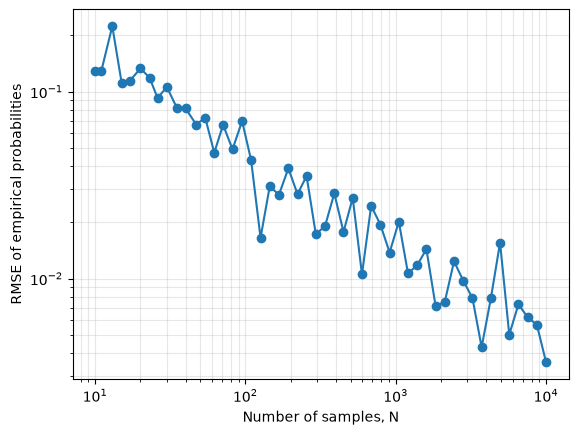

In [57]:
trials_N = np.logspace(1, 4, 50).astype(int)
p_Ns = []

for N in trials_N:
    X = generate_chain(N)
    p_N = np.array([np.mean(X == k) for k in space])
    p_Ns.append(p_N)

p_Ns = np.array(p_Ns)

pi = np.array([(i+1)/21 for i in range(6)])

def RMSE(p_Ns): # Return array of [RMSEs] taking [[p(1),...,p(6)], ... , ]
    return np.sqrt(np.mean((p_Ns - pi)**2, axis=1))

# compute errors
errors = RMSE(p_Ns)

plt.loglog(trials_N, errors, "o-")
plt.xlabel("Number of samples, N")
plt.ylabel("RMSE of empirical probabilities")
plt.grid(True, which="both", alpha=0.3)
plt.show()


Clearly, there's some linear scaling in log space. So a power law fit for RMSE = N^p would be interesting.

In [58]:
from IPython.display import Math, display

# Fit RMSE(N) = A N^p by least squares in log space:
# log(RMSE) = log(A) + p log(N).
p, log_A = np.polyfit(np.log(trials_N), np.log(errors), 1)
A = np.exp(log_A)

display(Math(rf"\mathrm{{RMSE}}(N) \approx {A:.4f}\,N^{{{p:.4f}}}"))


<IPython.core.display.Math object>

$\Rightarrow$ RMSE scales approximately $\propto 1/\sqrt{N}$

**(b)** Construct its $6\times 6$ transition matrix, including the diagonal entries. Verify numerically that
$\pi$ is stationary and that detailed balance holds:

$$
\pi(x)P(x,y) = \pi(y)P(y,x).
$$

- The elements of the matrix $P(x,y)$ (where $x,y\in\{1,2,3,4,5,6\}$) are the conditional probabilities that, in a state $x$, the next value in the chain will be $y$, i.e. 

$$
P(x,y)=\Pr(X_{n+1}=y\mid X_n=x)
$$

- Consider the off-diagonal elements $x\neq y$. $y$ is chosen uniformly from the sample space, i.e. with probability $1/6$. It cannot be rejected, so the only case is where (i) it is chosen randomly, and (ii) it is accepted with probability $a(x,y)$. So

$$
P(x,y) = (1/6)\cdot a(x,y) = (1/6)\cdot\min(1,\frac{y}{x}) \qquad [x \neq y]
$$

- For diagonal elements $x=y$, these occur when any of the proposals are rejected, or if $x$ is proposed and accepted, already given $x$. i.e.

$$
\begin{aligned}
P(x,x) &= 1 - \sum_{y\neq x} P(x,y), \\
       &= 1 - \sum_{y\neq x} (1/6)\cdot\min(1,\frac{y}{x}).
\end{aligned}
$$

- So, to actually compute the matrix elements we would just have to, for each $x,y$, evaluate the sum in the relevant expression. In the lower triangle it has a simple pattern since the second term $y/x$ in the $\min()$ is evaluated and multipled by $1/6$. Diagonals need to compute the $\min()$ 5 times with less symmetry. The upper triangle is always just $1/6$ since the $\min()$ always takes $1$, multipled by $1/6$. 

In [59]:
# Compute the matrix

P = np.zeros((6, 6))

for i, x in enumerate(space):
    for j, y in enumerate(space):
        if x != y:
            P[i, j] = (1 / 6) * min(1, y / x)

    P[i, i] = 1 - np.sum(P[i])

rows = [" & ".join(f"{v:.4f}" for v in row) for row in P]
latex = r"P_{xy} = \begin{pmatrix}" + r" \\ ".join(rows) + r"\end{pmatrix}"

display(Math(latex))

<IPython.core.display.Math object>

These are analytical values for $P(x,y)$. To infer from the Markov chain, we take

$$
\hat P(x,y) =
\frac{\text{\# of transitions }x\to y}
{\text{\# of transitions starting at }x}.
$$

In [60]:
counts = np.zeros((6, 6))

for x, y in zip(X[:-1], X[1:]): # zip pairs every x with it's subsequent element y
    counts[int(x) - 1, int(y) - 1] += 1

row_totals = counts.sum(axis=1)

# divide each matrix element by the sum of its rows
P_hat = np.divide(
    counts,
    row_totals,
    out=np.full((6, 6), np.nan)
    )

flow = pi[:, None] * P_hat # pi(x)P_hat(x,y). flow.T = p(y)P_hat(y,x)
balance_error = np.max(np.abs(flow - flow.T))

print("Maximum detailed-balance error:", balance_error)


Maximum detailed-balance error: 0.043373705577584284


**(c)** Explain why the sampler does not need $Z$. Repeat the simulation after multiplying every
weight by the same positive constant.

- The acceptance probability has the form $a(x,y) = \min(1, \frac{w(y)}{w(x)})$. If we multiply each weight by the same (positive) constant, the ratio $w(y)/w(x)$ remains identical.

**1.2. A reusable Metropolis sampler.** Write a reusable function for sampling
$$
\pi_\beta(x) = \frac{e^{−\beta H(x)}}{Z}
$$
The function should accept the Hamiltonian, inverse temperature, initial state, proposal rule,
and simulation length. Allow an optional function that computes the energy change without
recomputing the full Hamiltonian. Keep model-specific operations outside the sampling driver.

- Proposal rule: given $x$, draw the proposal $y = x + \varepsilon(U-\frac{1}{2})$

In [ ]:
from collections.abc import Callable # type annotations for hamiltonian as arg

def should_reject(beta, dH) -> bool:
    u = rand()
    if np.log(u) < min(0, -beta*dH):
        return False
    else: 
        return True

def step(x, beta, H, rule, eps):

    RULES = {"uniform_eps"}
    if not(rule in RULES): 
        raise ValueError(
            f"Unknown proposal rule {rule}.\n"
            f"Expected one of: {', '.join(RULES)}"
        )

    if rule == "uniform_eps":
        u = rand()
        y = x + eps * (u - 1/2)
        dH = H(y) - H(x)

    if should_reject(beta,dH):
        return x
    else:
        return y



def generate_chain(
        H: Callable[[float], float], 
        beta, 
        x_init, 
        N, 
        rule="uniform_eps", 
        eps = 0.5
        ): # return array of length N
    
    X = np.zeros(N)
    X[0] = x_init

    for i in range(N-1):
        X[i+1] = step(X[i], beta, H, rule, eps)

    return X


**1.3. The one-dimensional Ising model.** Consider $N$ spins $s_i \in \{−1,+1\}$ on a periodic chain:
$$
H(\mathbf{s}) =−J\sum_{i=1}^N s_i s_{i+1} −g\sum_{i=1}^N s_i, \qquad s_{N+1} = s_1.
$$
Here $g$ is an external magnetic field. Use $g = 0$ unless stated otherwise.

At each proposal attempt, choose a site uniformly and propose flipping its spin. Define one Monte
Carlo sweep as $N$ proposal attempts, with sites selected independently.

**(a)** Derive the local energy change
$$
\Delta H = 2s_i J(s_{i−1} + s_{i+1}) + g.
$$
Check your implementation against direct differences of the full Hamiltonian for randomly selected
configurations and sites.